In [1]:
import os
import numpy as np

from gsm_benchmarker.results_analyser.bootstrap_result import BootstrapResult

from results_notebook_setup import RESULTS_ROOT, RESULTS_FOLDERS


100%|██████████| 2/2 [00:00<00:00,  2.17it/s]


In [2]:
RESULTS_FOLDERS.keys()

dict_keys(['gsm', 'nonformal', 'formal', 'short_code', 'long_code'])

In [3]:
boot_path = (RESULTS_ROOT / RESULTS_FOLDERS['gsm']).parent / 'bootstrap'
print(boot_path)
os.listdir(boot_path)

/home/guests2/dkd/data/gsm-symbolic/outputs/noq_default_full__12_05/bootstrap


['n_boot_5__variant_effect.pkl',
 'boot2000_checkpoints.pkl',
 'n_boot_2000__variant_effect__checkpoints.pkl',
 'n_boot_5__glmm2.pkl',
 'boot5.csv',
 'n_boot_5__glmm2__checkpoints.pkl',
 'n_boot_2000__variant_effect.pkl',
 'n_boot_5__variant_effect__checkpoints.pkl',
 'boot5_checkpoints.pkl',
 'n_boot_5__glmm1.pkl',
 'n_boot_5__glmm1__wald.pkl',
 'boot2000.csv',
 'n_boot_5__number_effect__checkpoints.pkl',
 'n_boot_2000__number_effect__checkpoints.pkl',
 'n_boot_5__glmm1__checkpoints.pkl',
 'boot3_checkpoints.pkl',
 'boot3.csv',
 'boot10.csv',
 'n_boot_2000__number_effect.pkl',
 'n_boot_5__glmm2__wald.pkl',
 'logs',
 'boot2.csv',
 'n_boot_5__number_effect.pkl']

In [4]:
n_boot = 5

bs1 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='1')
bs2 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='2')


## GLMM 1 - variant effect

In [5]:
bs1.boot_numbers  # bootstrap stats

,,requested,failed,nonconverged,singular,clean
Mathstral-7B-v0.1,is_variant,5.0,0.0,0.0,0.0,5.0
Meta-Llama-3-8B,is_variant,5.0,0.0,0.0,0.0,5.0
Meta-Llama-3-8B-Instruct,is_variant,5.0,0.0,0.0,0.0,5.0
Mistral-7B-Instruct-v0.1,is_variant,5.0,0.0,0.0,0.0,5.0
Mistral-7B-Instruct-v0.3,is_variant,5.0,0.0,0.0,0.0,5.0
Mistral-7B-v0.1,is_variant,5.0,0.0,0.0,0.0,5.0
Mistral-7B-v0.3,is_variant,5.0,0.0,0.0,0.0,5.0
Phi-3-medium-128k-instruct,is_variant,5.0,0.0,0.0,0.0,5.0
Phi-3-mini-128k-instruct,is_variant,5.0,0.0,0.0,0.0,5.0
Phi-3.5-mini-instruct,is_variant,5.0,0.0,0.0,0.0,5.0


In [6]:
# summary of clean estimates
bs1.boot_df

,,ci_upper_log,ci_lower_log,se_log,mean_log,median_log,p_value,n_requested,n_failed,n_nonconverged,n_singular,n_clean,elapsed_seconds,significant,ci_width_log
Mathstral-7B-v0.1,is_variant,-0.213968,-1.141366,0.386068,-0.690052,-0.581450,0.0,5.0,0.0,0.0,0.0,5.0,11.151910,True,0.927398
Meta-Llama-3-8B,is_variant,-0.579981,-0.851048,0.108142,-0.698586,-0.675904,0.0,5.0,0.0,0.0,0.0,5.0,10.544985,True,0.271067
Meta-Llama-3-8B-Instruct,is_variant,-0.462366,-1.020867,0.255392,-0.659086,-0.530554,0.0,5.0,0.0,0.0,0.0,5.0,12.286094,True,0.558502
Mistral-7B-Instruct-v0.1,is_variant,-0.142926,-0.600097,0.196079,-0.437855,-0.495248,0.0,5.0,0.0,0.0,0.0,5.0,10.331444,True,0.457171
Mistral-7B-Instruct-v0.3,is_variant,-0.533424,-0.945041,0.173831,-0.678875,-0.624189,0.0,5.0,0.0,0.0,0.0,5.0,10.377162,True,0.411617
Mistral-7B-v0.1,is_variant,0.191429,-0.603839,0.339372,-0.312599,-0.357371,0.4,5.0,0.0,0.0,0.0,5.0,10.744382,False,0.795267
Mistral-7B-v0.3,is_variant,0.487596,-0.104351,0.248861,0.188800,0.250891,0.8,5.0,0.0,0.0,0.0,5.0,10.209280,False,0.591946
Phi-3-medium-128k-instruct,is_variant,-0.816399,-2.004185,0.480833,-1.338593,-1.326641,0.0,5.0,0.0,0.0,0.0,5.0,12.738969,True,1.187786
Phi-3-mini-128k-instruct,is_variant,0.037945,-0.560892,0.291308,-0.348988,-0.551416,0.4,5.0,0.0,0.0,0.0,5.0,12.756790,False,0.598837
Phi-3.5-mini-instruct,is_variant,-0.230335,-1.922559,0.681668,-1.157132,-1.250129,0.0,5.0,0.0,0.0,0.0,5.0,12.495114,True,1.692223


In [7]:
# check how many models agree w.r.t. significance of the result; show the ones that don't
bs1.disagreements_check()

Agreement: 16 / 20 models


,,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
Mistral-7B-Instruct-v0.3,is_variant,-0.945041,-0.533424,-1.035430,0.034589,0.066765,False
Phi-3-medium-128k-instruct,is_variant,-2.004185,-0.816399,-1.510168,0.379200,0.240705,False
gemma-2-27b-it,is_variant,-0.837011,-0.015629,-1.462651,0.432102,0.286416,False
gemma-2b-it,is_variant,-1.209801,-0.153912,-1.287536,0.338111,0.252343,False


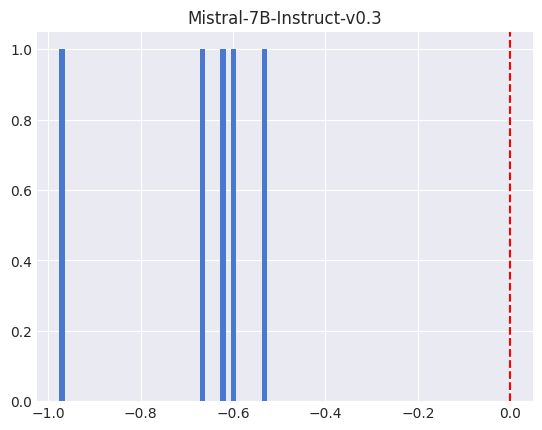

Mistral-7B-Instruct-v0.3 / 'is_variant': skew=-1.74, % of resamples > 0: 0.0%


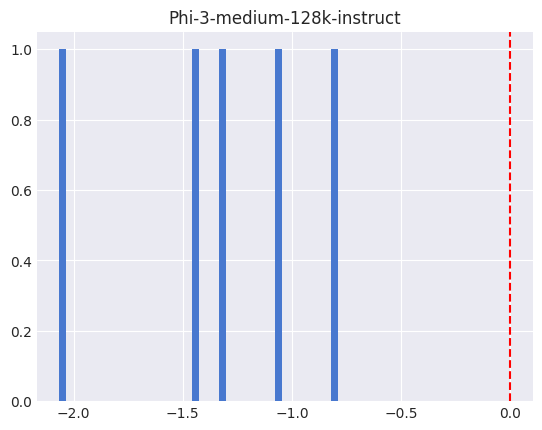

Phi-3-medium-128k-instruct / 'is_variant': skew=-0.74, % of resamples > 0: 0.0%


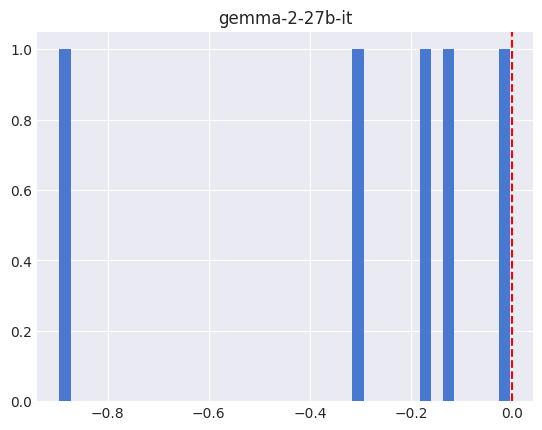

gemma-2-27b-it / 'is_variant': skew=-1.71, % of resamples > 0: 0.0%


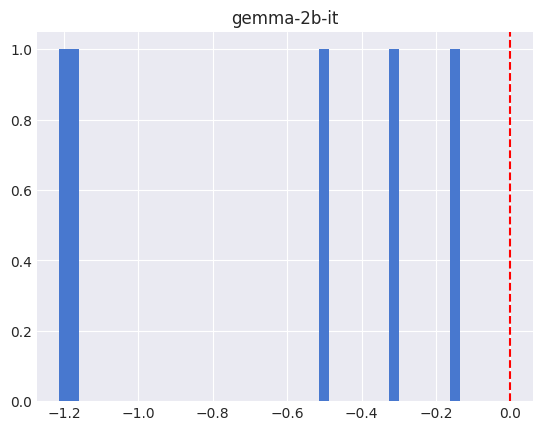

gemma-2b-it / 'is_variant': skew=-0.30, % of resamples > 0: 0.0%


In [8]:
# plot the distribution of estimates in the bootstrap for models which do not agree with single GLMM significance verdict
bs1.plot_nonagreeing_estimates('is_variant')

For all models - also the agreeing ones

In [9]:
# quick scan for any other model where bootstrap mean diverges meaningfully from the original estimate
# (bias is <bootstrap mean estimate> minus <single GLMM estimate>
bs1.bias_check('is_variant')


,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
Phi-3-medium-128k-instruct,-0.761156,-1.338593,-1.326641,-0.565484,-1.510168,0.379200
Phi-3-mini-128k-instruct,-0.396668,-0.348988,-0.551416,-0.154748,-0.843341,0.533846
gemma-2-27b-it,0.341963,-0.301218,-0.173312,-0.515275,-1.462651,0.432102
gemma-7b-it,0.291561,-0.432840,-0.416023,-0.707585,-1.259303,-0.155866
Mistral-7B-Instruct-v0.1,0.192572,-0.437855,-0.495248,-0.687820,-1.222734,-0.152906
Meta-Llama-3-8B-Instruct,0.191697,-0.659086,-0.530554,-0.722251,-1.363405,-0.081097
gemma-2-9b-it,-0.176586,-0.496459,-0.690003,-0.513418,-1.316719,0.289884
gemma-7b,-0.162826,-0.052028,-0.185994,-0.023168,-0.565213,0.518877
Mathstral-7B-v0.1,0.160226,-0.690052,-0.581450,-0.741676,-1.415893,-0.067458
gemma-2-2b-it,0.150037,0.119070,0.133812,-0.016225,-0.599179,0.566729


In [10]:
# CI width ratio (bootstrap CI width / original CI width) across all models, excluding the ones which did not converge for single GLMM
bs1.ci_width_check('is_variant')

,width_ratio_log
count,19.000000
mean,0.526986
std,0.214148
min,0.110511
25%,0.430417
50%,0.522797
75%,0.639150
max,1.044561


In [11]:
# bootstrap estimate distribution skew check across all models
bs1.skew_check('is_variant')

Models with absolute skew > 0.5:
	 Meta-Llama-3-8B -0.8255541532960926
	 Meta-Llama-3-8B-Instruct -1.0817350192229465
	 Mistral-7B-Instruct-v0.1 1.506806286470126
	 Mistral-7B-Instruct-v0.3 -1.738340416297762
	 Mistral-7B-v0.1 1.405052882567934
	 Phi-3-medium-128k-instruct -0.7353429860814072
	 Phi-3-mini-128k-instruct 0.8468710802082746
	 Phi-3.5-mini-instruct 0.5819437295531467
	 gemma-2-27b-it -1.708016183583134
	 gemma-2-2b-it -1.0836951495433165
	 gemma-2-9b-it 1.0366488192340597


## GLMM2

In [12]:
bs2.boot_numbers.xs('is_variant', level=1)  # shared for both variables


,requested,failed,nonconverged,singular,clean
Mathstral-7B-v0.1,5.0,0.0,0.0,0.0,5.0
Meta-Llama-3-8B,5.0,0.0,0.0,0.0,5.0
Meta-Llama-3-8B-Instruct,5.0,0.0,0.0,0.0,5.0
Mistral-7B-Instruct-v0.1,5.0,0.0,1.0,0.0,4.0
Mistral-7B-Instruct-v0.3,5.0,0.0,0.0,0.0,5.0
Mistral-7B-v0.1,5.0,0.0,0.0,0.0,5.0
Mistral-7B-v0.3,5.0,0.0,0.0,0.0,5.0
Phi-3-medium-128k-instruct,5.0,0.0,0.0,0.0,5.0
Phi-3-mini-128k-instruct,5.0,0.0,0.0,0.0,5.0
Phi-3.5-mini-instruct,5.0,0.0,0.0,0.0,5.0


### a) number effect

In [13]:
bs2.disagreements_check('gamma_c')

Agreement: 14 / 20 models


,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
Meta-Llama-3-8B-Instruct,-0.312867,-0.052158,-0.275425,0.004208,0.057306,False
Mistral-7B-Instruct-v0.3,-0.148550,-0.041049,-0.195514,0.054099,0.266832,False
Phi-3-mini-128k-instruct,-0.145708,-0.027841,-0.289013,0.005527,0.059239,False
gemma-2-27b-it,0.076735,0.350754,-0.117157,0.335488,0.344466,False
gemma-2-2b-it,-0.204680,-0.004623,-0.220022,0.066300,0.292674,False
gemma-2-9b,0.031699,0.221197,-0.102102,0.185411,0.570093,False


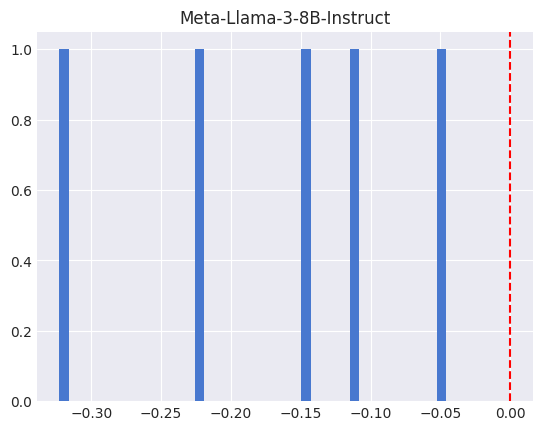

Meta-Llama-3-8B-Instruct / 'gamma_c': skew=-0.58, % of resamples > 0: 0.0%


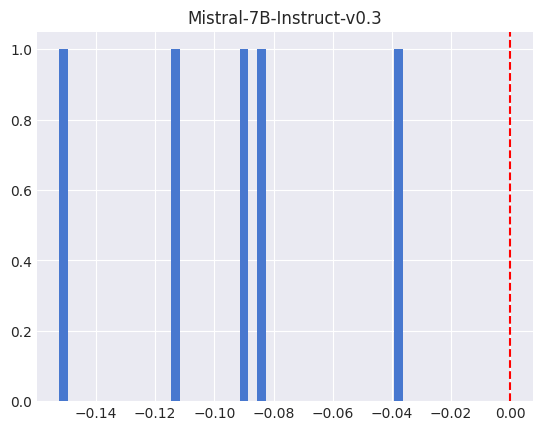

Mistral-7B-Instruct-v0.3 / 'gamma_c': skew=0.08, % of resamples > 0: 0.0%


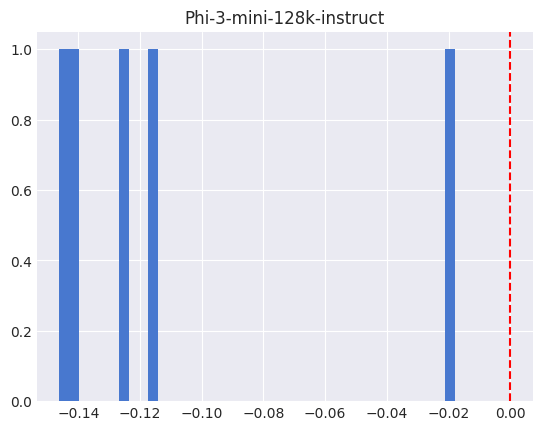

Phi-3-mini-128k-instruct / 'gamma_c': skew=1.94, % of resamples > 0: 0.0%


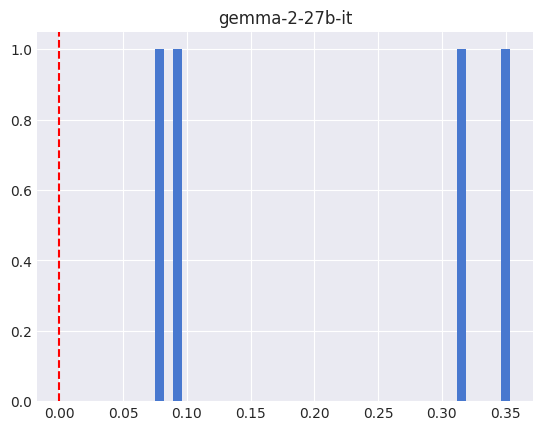

gemma-2-27b-it / 'gamma_c': skew=0.05, % of resamples > 0: 100.0%


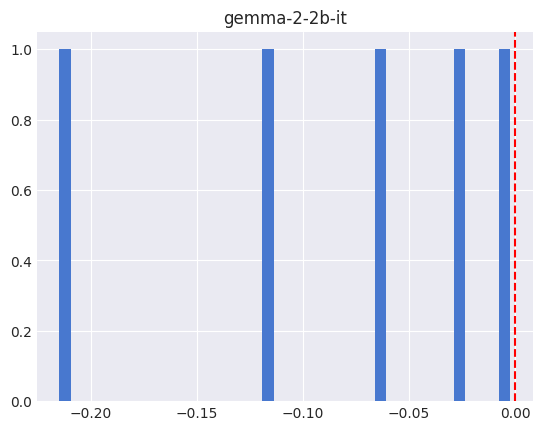

gemma-2-2b-it / 'gamma_c': skew=-1.04, % of resamples > 0: 0.0%


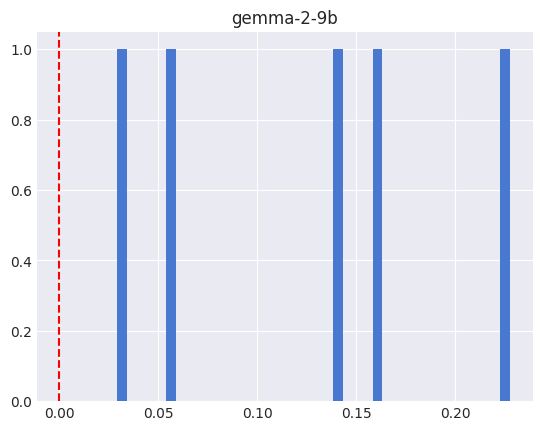

gemma-2-9b / 'gamma_c': skew=0.04, % of resamples > 0: 100.0%


In [14]:
bs2.plot_nonagreeing_estimates('gamma_c')

In [15]:
bs2.bias_check('gamma_c')

,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
gemma-2-9b,0.099900,0.123407,0.141555,0.041655,-0.102102,0.185411
gemma-2-27b-it,0.096005,0.209805,0.205170,0.109166,-0.117157,0.335488
Mistral-7B-v0.1,0.085246,-0.062268,-0.010437,-0.095683,-0.225734,0.034368
Phi-3-medium-128k-instruct,-0.070759,-0.349180,-0.341189,-0.270430,-0.442549,-0.098312
Phi-3.5-mini-instruct,-0.067492,-0.368596,-0.366086,-0.298593,-0.450793,-0.146394
gemma-7b,0.064851,0.006367,0.022980,-0.041871,-0.168821,0.085079
gemma-2-2b,-0.063513,-0.270456,-0.265439,-0.201926,-0.202824,-0.201027
Mathstral-7B-v0.1,-0.045511,-0.098091,-0.154718,-0.109207,-0.240551,0.022136
gemma-2b,0.042706,-0.127209,-0.125900,-0.168607,-0.329908,-0.007305
Mistral-7B-v0.3,0.042161,0.025924,0.053126,0.010965,-0.120659,0.142589


In [16]:
bs2.ci_width_check('gamma_c')

,width_ratio_log
count,19.000000
mean,0.700604
std,0.227386
min,0.322888
25%,0.599641
50%,0.674309
75%,0.837126
max,1.295810


In [17]:
bs2.skew_check('gamma_c')

Models with absolute skew > 0.5:
	 Mathstral-7B-v0.1 1.0110519100361024
	 Meta-Llama-3-8B-Instruct -0.5793206462717281
	 Mistral-7B-v0.3 -1.9986066055636986
	 Phi-3-mini-128k-instruct 1.9439301270755827
	 Phi-3.5-mini-instruct -0.8232721106472151
	 gemma-2-2b -0.7246114394321451
	 gemma-2-2b-it -1.044210210327276
	 gemma-2b-it -1.8759953144131658
	 gemma-7b-it 0.7505611075468177


### b) number-effect-corrected variant effect

In [18]:
bs2.disagreements_check('is_variant')

Agreement: 16 / 20 models


,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
Meta-Llama-3-8B-Instruct,-0.821333,-0.091451,-1.190757,0.154354,0.131006,False
Mistral-7B-Instruct-v0.3,-0.878125,-0.456654,-0.991754,0.116861,0.121921,False
Phi-3-medium-128k-instruct,-1.560566,-0.471733,-1.217124,0.715579,0.611019,False
gemma-2-2b,-0.031949,0.083980,-0.097989,-0.096192,0.000000,True


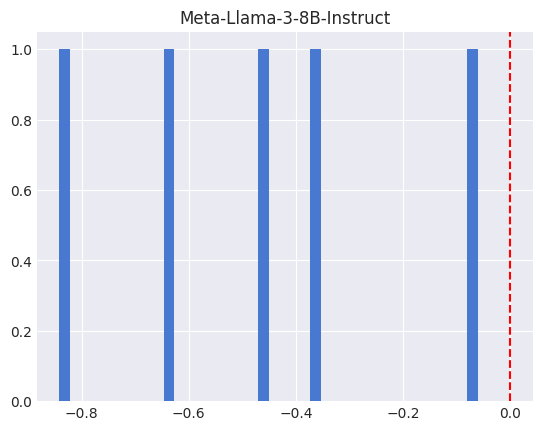

Meta-Llama-3-8B-Instruct / 'is_variant': skew=0.30, % of resamples > 0: 0.0%


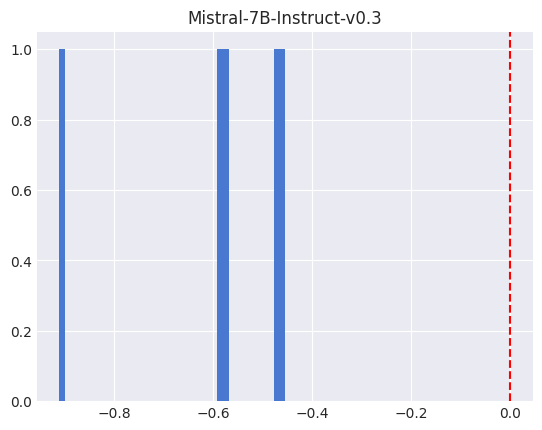

Mistral-7B-Instruct-v0.3 / 'is_variant': skew=-1.69, % of resamples > 0: 0.0%


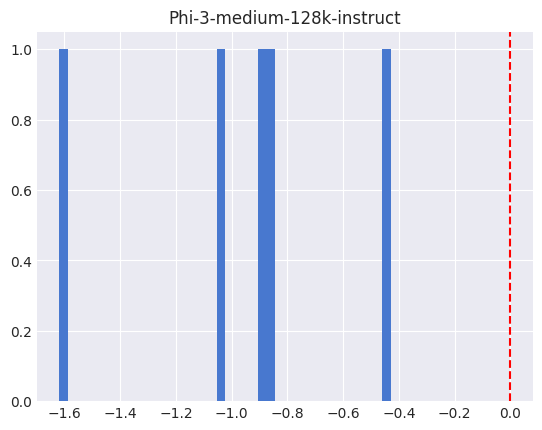

Phi-3-medium-128k-instruct / 'is_variant': skew=-0.66, % of resamples > 0: 0.0%


In [19]:
bs2.plot_nonagreeing_estimates('is_variant')

In [20]:
bs2.bias_check('is_variant')


,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
Phi-3-medium-128k-instruct,-0.630082,-0.963813,-0.880854,-0.250772,-1.217124,0.715579
Phi-3-mini-128k-instruct,-0.334614,-0.284532,-0.402639,-0.068026,-0.778677,0.642625
Mistral-7B-Instruct-v0.1,0.243171,-0.143776,-0.163219,-0.406389,-0.961617,0.148839
gemma-7b-it,0.185277,-0.283493,-0.367740,-0.553017,-1.128229,0.022196
phi-2,0.150174,-1.101728,-1.024506,-1.174679,-1.735486,-0.613873
Mistral-7B-Instruct-v0.3,-0.134440,-0.599631,-0.571886,-0.437447,-0.991754,0.116861
Phi-3.5-mini-instruct,-0.127867,-0.527954,-0.663258,-0.535392,-1.391197,0.320413
gemma-2-9b-it,-0.127719,-0.400390,-0.382005,-0.254286,-1.119678,0.611106
gemma-7b,-0.091841,-0.070519,-0.073892,0.017950,-0.540917,0.576816
gemma-2-2b-it,0.085478,0.215128,0.157243,0.071765,-0.534586,0.678116


In [21]:

bs2.ci_width_check('is_variant')

,width_ratio_log
count,19.000000
mean,0.535525
std,0.175517
min,0.158447
25%,0.464448
50%,0.490265
75%,0.678864
max,0.835507


In [22]:

bs2.skew_check('is_variant')

Models with absolute skew > 0.5:
	 Mathstral-7B-v0.1 1.3201710378134521
	 Mistral-7B-Instruct-v0.3 -1.6911048231277215
	 Mistral-7B-v0.1 0.9158856082286937
	 Phi-3-medium-128k-instruct -0.6626231774030124
	 Phi-3.5-mini-instruct 1.0412280980466142
	 gemma-2-27b-it 0.5282271852079251
	 gemma-2-2b 1.7309025203748554
	 gemma-2-9b -1.320899106711574
	 gemma-7b -0.54926514446678


---
# Combined analysis for all prompt formats

In [23]:
boots = {
    'GLMM1': {},
    'GLMM2': {},
}

for prompt_name, prompt_folder in RESULTS_FOLDERS.items():
    boot_path = (RESULTS_ROOT / prompt_folder).parent / 'bootstrap'

    bs1 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='1')

    bs2 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='2')

    boots['GLMM1'][prompt_name] = bs1
    boots['GLMM2'][prompt_name] = bs2



In [24]:
bs2.summary_df.xs('is_variant', level=1)

,boot_ci_upper_log,boot_ci_lower_log,boot_se_log,boot_mean_log,boot_median_log,boot_p_value,boot_n_requested,boot_n_failed,boot_n_nonconverged,boot_n_singular,...,wald_singular,wald_nonconvergent,wald_fit_failed,wald_ranef_variance,wald_ranef_sd,wald_significant,wald_ci_width_log,agreement,width_ratio_log,bias_log
Mathstral-7B-v0.1,0.736217,-0.055922,0.345208,0.199869,0.068583,0.4,5.0,0.0,0.0,0.0,...,False,False,False,19.067956,4.366687,False,1.662463,True,0.476485,-0.142509
Meta-Llama-3-8B,0.391886,-0.192565,0.237454,0.063135,-0.009603,0.8,5.0,0.0,0.0,0.0,...,False,False,False,15.797836,3.974649,False,1.284331,True,0.455062,-0.136303
Meta-Llama-3-8B-Instruct,-0.325794,-0.755295,0.180706,-0.497673,-0.491930,0.0,5.0,0.0,0.0,0.0,...,False,False,False,9.618717,3.101406,False,1.376838,False,0.311948,-0.274390
Mistral-7B-Instruct-v0.1,0.072950,-0.622514,0.304807,-0.261514,-0.343099,0.8,5.0,0.0,0.0,0.0,...,False,False,False,10.787091,3.284371,False,1.214328,True,0.572715,-0.032695
Phi-3.5-mini-instruct,-0.071001,-0.904059,0.351282,-0.366870,-0.261436,0.0,5.0,0.0,0.0,0.0,...,False,False,False,26.256294,5.124090,False,1.661422,False,0.501413,0.037834
gemma-2-2b,-0.083636,-0.116032,0.024113,-0.099834,-0.099834,0.0,5.0,0.0,3.0,0.0,...,False,True,False,7.946997,2.819042,True,0.001717,True,18.866000,0.173565
gemma-2-9b,0.472219,-1.175686,0.850345,-0.438318,-0.540182,1.0,5.0,0.0,1.0,0.0,...,False,False,False,16.748927,4.092545,False,1.473650,True,1.118247,-0.544872
gemma-2b,-0.149435,-0.910542,0.305862,-0.570546,-0.573335,0.0,5.0,0.0,0.0,0.0,...,False,False,False,6.274512,2.504898,False,1.489231,False,0.511074,-0.245739
gemma-7b-it,0.392510,-0.052909,0.206404,0.122045,0.065861,0.5,5.0,0.0,1.0,0.0,...,False,False,False,16.217206,4.027059,False,1.316646,True,0.338298,0.165447
phi-2,0.126899,-0.533379,0.301550,-0.223374,-0.247061,0.5,5.0,0.0,1.0,0.0,...,False,False,False,18.875712,4.344619,False,1.378819,True,0.478872,0.028535


In [25]:
import pandas as pd

def combine_prompt_boots(glmm_key, effect):
    return pd.concat({key: value.summary_df.xs(effect, level=1) for key, value in boots[glmm_key].items()}, axis=0, names=['prompt', 'model'])

boots_combined = {
    'GLMM1-is_variant': combine_prompt_boots('GLMM1', 'is_variant'),
    'GLMM2-is_variant': combine_prompt_boots('GLMM2', 'is_variant'),
    'GLMM2-gamma_c': combine_prompt_boots('GLMM2', 'gamma_c')
}

boots_combined['GLMM1-is_variant']

boot_ci_upper_log  boot_ci_lower_log  \
prompt     model                                                              
gsm        Mathstral-7B-v0.1                   -0.213968          -1.141366   
           Meta-Llama-3-8B                     -0.579981          -0.851048   
           Meta-Llama-3-8B-Instruct            -0.462366          -1.020867   
           Mistral-7B-Instruct-v0.1            -0.142926          -0.600097   
           Mistral-7B-Instruct-v0.3            -0.533424          -0.945041   
           Mistral-7B-v0.1                      0.191429          -0.603839   
           Mistral-7B-v0.3                      0.487596          -0.104351   
           Phi-3-medium-128k-instruct          -0.816399          -2.004185   
           Phi-3-mini-128k-instruct             0.037945          -0.560892   
           Phi-3.5-mini-instruct               -0.230335          -1.922559   
           gemma-2-27b-it                      -0.015629          -0.837011   
           gemma-2-2b                          -0.227675          -0.580608   
           gemma-2-2b-it                        0.256315          -0.095355   
           gemma-2-9b                          -0.686853          -0.831140   
           gemma-2-9b-it                        0.142266          -0.867935   
           gemma-2b                            -0.377271          -1.076469   
           gemma-2b-it                         -0.153912          -1.209801   
           gemma-7b                             0.380492          -0.511680   
           gemma-7b-it                         -0.127051          -0.725019   
           phi-2                               -1.124530          -1.651418   
nonformal  Mathstral-7B-v0.1                   -0.102632          -0.821179   
           Meta-Llama-3-8B                     -0.356262          -0.605270   
           Meta-Llama-3-8B-Instruct            -0.018948          -0.535493   
           Mistral-7B-Instruct-v0.1            -0.478462          -0.478462   
           Phi-3.5-mini-instruct                0.290002          -0.493503   
           gemma-2-2b                          -0.224873          -0.878473   
           gemma-2-9b                          -0.730544          -1.570772   
           gemma-2b                            -1.275040          -1.509253   
           gemma-7b-it                          0.631414          -0.072334   
           phi-2                               -0.693115          -1.466246   
formal     Mathstral-7B-v0.1                   -0.006418          -0.664260   
           Meta-Llama-3-8B                      0.459461          -0.609146   
           Meta-Llama-3-8B-Instruct            -0.459017          -1.196592   
           Mistral-7B-Instruct-v0.1            -0.119918          -0.644411   
           Phi-3.5-mini-instruct                0.263572          -0.424695   
           gemma-2-2b                          -0.382974          -0.751614   
           gemma-2-9b                           0.745660          -0.881390   
           gemma-2b                             0.353548          -0.055604   
           gemma-7b-it                          0.430997          -0.500481   
           phi-2                               -1.303283          -1.869504   
short_code Mathstral-7B-v0.1                    0.821325           0.204837   
           Meta-Llama-3-8B                      1.016296           0.118531   
           Meta-Llama-3-8B-Instruct            -0.162463          -0.877029   
           Mistral-7B-Instruct-v0.1             0.850529           0.046241   
           Phi-3.5-mini-instruct               -0.458977          -1.240064   
           gemma-2-2b                          -0.092205          -0.251676   
           gemma-2-9b                           0.124020          -0.698045   
           gemma-2b                             0.249141          -0.237959   
           gemma-7b-it                         -0.234647          -0.968973   
          

In [27]:
original_significance = boots_combined['GLMM1-is_variant'].xs('gsm', level='prompt').wald_significant
significant_models = original_significance[original_significance].index.tolist()
significant_models

['Mathstral-7B-v0.1',
 'Meta-Llama-3-8B',
 'Meta-Llama-3-8B-Instruct',
 'Mistral-7B-Instruct-v0.1',
 'Phi-3.5-mini-instruct',
 'gemma-2-2b',
 'gemma-2-9b',
 'gemma-2b',
 'gemma-7b-it',
 'phi-2']

In [28]:
for combo_key, combo_summary in boots_combined.items():
    for prompt_name in combo_summary.index.get_level_values('prompt').unique():
        if 'GLMM1' in combo_key and prompt_name == 'gsm':
            continue
        for model_name in combo_summary.xs(prompt_name, level='prompt').index:
            if model_name not in significant_models:
                combo_summary.drop(index=(prompt_name, model_name), inplace=True)


In [29]:
combo_summary

boot_ci_upper_log  boot_ci_lower_log  \
prompt     model                                                            
gsm        Mathstral-7B-v0.1                  0.045163          -0.177190   
           Meta-Llama-3-8B                    0.270124          -0.115033   
           Meta-Llama-3-8B-Instruct          -0.052158          -0.312867   
           Mistral-7B-Instruct-v0.1          -0.170361          -0.340742   
           Phi-3.5-mini-instruct             -0.257473          -0.509453   
           gemma-2-2b                        -0.244095          -0.301083   
           gemma-2-9b                         0.221197           0.031699   
           gemma-2b                          -0.076239          -0.180404   
           gemma-7b-it                       -0.048713          -0.202397   
           phi-2                             -0.214686          -0.359574   
nonformal  Mathstral-7B-v0.1                 -0.160089          -0.350188   
           Meta-Llama-3-8B                   -0.028644          -0.240280   
           Meta-Llama-3-8B-Instruct           0.032116          -0.187656   
           Mistral-7B-Instruct-v0.1          -0.194039          -0.238072   
           Phi-3.5-mini-instruct             -0.166585          -0.570965   
           gemma-2-2b                        -0.112075          -0.251426   
           gemma-2-9b                        -0.175271          -0.360031   
           gemma-2b                          -0.034629          -0.332439   
           gemma-7b-it                       -0.130745          -0.280210   
           phi-2                             -0.148219          -0.518311   
formal     Mathstral-7B-v0.1                 -0.211972          -0.287439   
           Meta-Llama-3-8B                    0.409090          -0.081551   
           Meta-Llama-3-8B-Instruct          -0.312920          -0.363666   
           Mistral-7B-Instruct-v0.1          -0.145187          -0.285066   
           Phi-3.5-mini-instruct             -0.153981          -0.413202   
           gemma-2-2b                        -0.058359          -0.172558   
           gemma-2-9b                        -0.045227          -0.255732   
           gemma-2b                          -0.141158          -0.369332   
           gemma-7b-it                       -0.176080          -0.294783   
           phi-2                             -0.319229          -0.668073   
short_code Mathstral-7B-v0.1                 -0.063082          -0.239391   
           Meta-Llama-3-8B                    0.276342           0.122279   
           Meta-Llama-3-8B-Instruct           0.158054          -0.069604   
           Mistral-7B-Instruct-v0.1           0.126973          -0.067532   
           Phi-3.5-mini-instruct              0.228687          -0.031924   
           gemma-2-2b                        -0.138323          -0.183071   
           gemma-2-9b                         0.350913          -0.020065   
           gemma-2b                           0.075021          -0.185923   
           gemma-7b-it                       -0.188790          -0.323886   
           phi-2                             -0.016263          -0.297768   
long_code  Mathstral-7B-v0.1                  0.079408          -0.481498   
           Meta-Llama-3-8B                    0.035416          -0.173837   
           Meta-Llama-3-8B-Instruct           0.277072          -0.082908   
           Mistral-7B-Instruct-v0.1           0.102235          -0.012691   
           Phi-3.5-mini-instruct             -0.037684          -0.399243   
           gemma-2-2b                        -0.040450          -0.154806   
           gemma-2-9b                         0.015442          -0.207240   
           gemma-2b                           0.068641          -0.109411   
           gemma-7b-it                       -0.122954          -0.437345   
           phi-2                              0.032916          -0.038943   

                                

In [34]:
def make_summary(c):
    prompt_group = c.reset_index().groupby('prompt')

    n_models = prompt_group.size()
    n_agreement = prompt_group.agreement.sum()

    convergent_prompt_group = c[~c.wald_nonconvergent].reset_index().groupby('prompt')
    width_ratio_mean = convergent_prompt_group.width_ratio_log.mean()
    width_ratio_sd = convergent_prompt_group.width_ratio_log.std()

    bias = convergent_prompt_group.bias_log

    s = pd.concat({
        'N models': n_models,
        'Agreement': pd.Series([f"{a}/{n}" for a, n in zip(n_agreement, n_models)], index=n_agreement.index),
        # 'N singular': prompt_group.single_singular.sum(),
        'N non-convergent': prompt_group.wald_nonconvergent.sum(),
        'CI width ratio: mean ± SD': pd.Series([f"{mean:.3f} ± {sd:.3f}" for mean, sd in zip(width_ratio_mean, width_ratio_sd)], index=width_ratio_mean.index),
        'Max|bias|': pd.Series(np.maximum(bias.max(), -bias.min()), index=width_ratio_mean.index),
    }, axis=1).loc[RESULTS_FOLDERS.keys()]
    return s

make_summary(boots_combined['GLMM1-is_variant'])

,N models,Agreement,N non-convergent,CI width ratio: mean ± SD,Max|bias|
prompt,,,,,
gsm,20,16/20,1,0.527 ± 0.214,0.761156
nonformal,10,4/10,0,0.415 ± 0.221,0.465845
formal,10,8/10,1,0.604 ± 0.263,0.415335
short_code,10,4/10,0,0.496 ± 0.189,0.414476
long_code,10,7/10,1,0.557 ± 0.317,0.350933


In [35]:
make_summary(boots_combined['GLMM2-is_variant'])

,N models,Agreement,N non-convergent,CI width ratio: mean ± SD,Max|bias|
prompt,,,,,
gsm,10,8/10,1,0.484 ± 0.199,0.243171
nonformal,10,6/10,1,0.491 ± 0.154,0.492048
formal,10,6/10,2,0.466 ± 0.288,0.469023
short_code,10,5/10,0,0.461 ± 0.225,0.455523
long_code,10,7/10,1,0.529 ± 0.236,0.544872


In [36]:
make_summary(boots_combined['GLMM2-gamma_c'])

,N models,Agreement,N non-convergent,CI width ratio: mean ± SD,Max|bias|
prompt,,,,,
gsm,10,8/10,1,0.752 ± 0.271,0.099900
nonformal,10,9/10,1,0.762 ± 0.330,0.109918
formal,10,8/10,2,0.648 ± 0.406,0.160562
short_code,10,5/10,0,0.646 ± 0.272,0.163651
long_code,10,8/10,1,0.789 ± 0.417,0.105470


In [37]:
boots_combined_single_df = pd.concat(boots_combined, names=['test'])
boots_combined_single_df

boot_ci_upper_log  \
test             prompt    model                                         
GLMM1-is_variant gsm       Mathstral-7B-v0.1                 -0.213968   
                           Meta-Llama-3-8B                   -0.579981   
                           Meta-Llama-3-8B-Instruct          -0.462366   
                           Mistral-7B-Instruct-v0.1          -0.142926   
                           Mistral-7B-Instruct-v0.3          -0.533424   
...                                                                ...   
GLMM2-gamma_c    long_code gemma-2-2b                        -0.040450   
                           gemma-2-9b                         0.015442   
                           gemma-2b                           0.068641   
                           gemma-7b-it                       -0.122954   
                           phi-2                              0.032916   

                                                     boot_ci_lower_log  \
test             prompt    model                                         
GLMM1-is_variant gsm       Mathstral-7B-v0.1                 -1.141366   
                           Meta-Llama-3-8B                   -0.851048   
                           Meta-Llama-3-8B-Instruct          -1.020867   
                           Mistral-7B-Instruct-v0.1          -0.600097   
                           Mistral-7B-Instruct-v0.3          -0.945041   
...                                                                ...   
GLMM2-gamma_c    long_code gemma-2-2b                        -0.154806   
                           gemma-2-9b                        -0.207240   
                           gemma-2b                          -0.109411   
                           gemma-7b-it                       -0.437345   
                           phi-2                             -0.038943   

                                                     boot_se_log  \
test             prompt    model                                   
GLMM1-is_variant gsm       Mathstral-7B-v0.1            0.386068   
                           Meta-Llama-3-8B              0.108142   
                           Meta-Llama-3-8B-Instruct     0.255392   
                           Mistral-7B-Instruct-v0.1     0.196079   
                           Mistral-7B-Instruct-v0.3     0.173831   
...                                                          ...   
GLMM2-gamma_c    long_code gemma-2-2b                   0.085118   
                           gemma-2-9b                   0.104273   
                           gemma-2b                     0.077554   
                           gemma-7b-it                  0.142709   
                           phi-2                        0.033489   

                                                     boot_mean_log  \
test             prompt    model                                     
GLMM1-is_variant gsm       Mathstral-7B-v0.1             -0.690052   
                           Meta-Llama-3-8B               -0.698586   
                           Meta-Llama-3-8B-Instruct      -0.659086   
                           Mistral-7B-Instruct-v0.1      -0.437855   
                           Mistral-7B-Instruct-v0.3      -0.678875   
...                                                            ...   
GLMM2-gamma_c    long_code gemma-2-2b                    -0.097628   
                           gemma-2-9b                    -0.069985   
                           gemma-2b                      -0.035920   
                           gemma-7b-it                   -0.254720   
                           phi-2                          0.004999   

                                                     boot_median_log  \
test             prompt    model                                       
GLMM1-is_variant gsm       Mathstral-7B-v0.1               -0.581450   
                           Meta-Llama-3-8B                 -0.675904   
                           Meta-Llama-3-8B-

In [39]:
boots_combined_single_df[~boots_combined_single_df.agreement][['wald_significant', 'wald_significant', 'wald_nonconvergent']].sort_values(['wald_nonconvergent']).sort_index(level='prompt')

wald_significant  \
test             prompt     model                                          
GLMM1-is_variant formal     Mathstral-7B-v0.1                      False   
                            Mistral-7B-Instruct-v0.1               False   
GLMM2-gamma_c    formal     gemma-2-2b                             False   
                            gemma-2-9b                             False   
GLMM2-is_variant formal     Phi-3.5-mini-instruct                   True   
                            gemma-2-2b                             False   
                            gemma-2b                               False   
                            gemma-7b-it                             True   
GLMM1-is_variant gsm        Mistral-7B-Instruct-v0.3               False   
                            Phi-3-medium-128k-instruct             False   
                            gemma-2-27b-it                         False   
                            gemma-2b-it                            False   
GLMM2-gamma_c    gsm        Meta-Llama-3-8B-Instruct               False   
                            gemma-2-9b                             False   
GLMM2-is_variant gsm        Meta-Llama-3-8B-Instruct               False   
                            gemma-2-2b                              True   
GLMM1-is_variant long_code  Meta-Llama-3-8B-Instruct               False   
                            Phi-3.5-mini-instruct                  False   
                            gemma-2b                               False   
GLMM2-gamma_c    long_code  Phi-3.5-mini-instruct                  False   
                            gemma-7b-it                            False   
GLMM2-is_variant long_code  Meta-Llama-3-8B-Instruct               False   
                            Phi-3.5-mini-instruct                  False   
                            gemma-2b                               False   
GLMM1-is_variant nonformal  Mathstral-7B-v0.1                      False   
                            Meta-Llama-3-8B                        False   
                            Meta-Llama-3-8B-Instruct               False   
                            Mistral-7B-Instruct-v0.1               False   
                            gemma-2-2b                             False   
                            gemma-2-9b                             False   
GLMM2-gamma_c    nonformal  gemma-7b-it                            False   
GLMM2-is_variant nonformal  Meta-Llama-3-8B                        False   
                            gemma-2-9b                             False   
                            gemma-7b-it                            False   
                            phi-2                                  False   
GLMM1-is_variant short_code Mathstral-7B-v0.1                      False   
                            Meta-Llama-3-8B-Instruct               False   
                            Mistral-7B-Instruct-v0.1               False   
                            Phi-3.5-mini-instruct                  False   
                            gemma-2-2b                             False   
                            phi-2                                  False   
GLMM2-gamma_c    short_code Mathstral-7B-v0.1                      False   
                            Meta-Llama-3-8B                        False   
                            gemma-2-2b                             False   
                            gemma-7b-it                            False   
                            phi-2                                  False   
GLMM2-is_variant short_code Mathstral-7B-v0.1                      False   
                            Meta-Llama-3-8B-Instruct               False   
                            Phi-3.5-mini-instruct                  False   
                            gemma-2-9b                             False   
                            phi-2                                  False   

                           

In [41]:
boots_combined_single_df[boots_combined_single_df.wald_nonconvergent][['agreement', 'wald_significant', 'boot_significant']]

agreement  \
test             prompt    model                                 
GLMM1-is_variant gsm       gemma-2-2b                     True   
                 formal    gemma-2-2b                     True   
                 long_code gemma-2-2b                     True   
GLMM2-is_variant gsm       gemma-2-2b                    False   
                 nonformal Mistral-7B-Instruct-v0.1       True   
                 formal    Phi-3.5-mini-instruct         False   
                           gemma-7b-it                   False   
                 long_code gemma-2-2b                     True   
GLMM2-gamma_c    gsm       gemma-2-2b                     True   
                 nonformal Mistral-7B-Instruct-v0.1       True   
                 formal    Phi-3.5-mini-instruct          True   
                           gemma-7b-it                    True   
                 long_code gemma-2-2b                     True   

                                                     wald_significant  \
test             prompt    model                                        
GLMM1-is_variant gsm       gemma-2-2b                            True   
                 formal    gemma-2-2b                            True   
                 long_code gemma-2-2b                            True   
GLMM2-is_variant gsm       gemma-2-2b                            True   
                 nonformal Mistral-7B-Instruct-v0.1              True   
                 formal    Phi-3.5-mini-instruct                 True   
                           gemma-7b-it                           True   
                 long_code gemma-2-2b                            True   
GLMM2-gamma_c    gsm       gemma-2-2b                            True   
                 nonformal Mistral-7B-Instruct-v0.1              True   
                 formal    Phi-3.5-mini-instruct                 True   
                           gemma-7b-it                           True   
                 long_code gemma-2-2b                            True   

                                                     boot_significant  
test             prompt    model                                       
GLMM1-is_variant gsm       gemma-2-2b                            True  
                 formal    gemma-2-2b                            True  
                 long_code gemma-2-2b                            True  
GLMM2-is_variant gsm       gemma-2-2b                           False  
                 nonformal Mistral-7B-Instruct-v0.1              True  
                 formal    Phi-3.5-mini-instruct                False  
                           gemma-7b-it                          False  
                 long_code gemma-2-2b                            True  
GLMM2-gamma_c    gsm       gemma-2-2b                            True  
                 nonformal Mistral-7B-Instruct-v0.1              True  
                 formal    Phi-3.5-mini-instruct                 True  
                           gemma-7b-it                           True  
                 long_code gemma-2-2b                            True